In [2]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

# Tự động phát hiện GPU nếu có
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
DATA_PATH = r"C:\Users\ADMIN\Desktop\Dữ Liệu\ToN\NF-ToN-IoT-V2.parquet"
LABEL_COL   = 'Label'
N_SELECT    = 20   
BATCH_SIZE  = 1024
NUM_WORKERS = 0
EPOCHS      = 2     
LR          = 3e-4       
D_MODEL     = 128         
N_HEADS     = 8
N_PERSIST   = 4
LMM_HIDDEN  = 128        
OUTLIER_TH  = 3.0
PRE_BATCH   = 50000
SWA_WINDOW  = 16
LMM_LAYERS  = 4           
HEAD_DROPOUT = 0.2        
LMM_DROPOUT  = 0.15
N_SELECT    = 20
WARMUP_EPOCHS      = 2         

FOCAL_GAMMA = 1.0        

N_APT_PHASES = 15


In [ ]:
df = pd.read_parquet(DATA_PATH)

# Giữ L4_SRC_PORT, L4_DST_PORT; chỉ drop FTP_COMMAND_RET_CODE
df = df.drop(columns=['FTP_COMMAND_RET_CODE'], errors='ignore')

# Xóa các dòng trùng lặp trên toàn bộ dữ liệu
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print('Total samples (Full Data after dedup):', df.shape)

# Tìm các cột hằng số (constant columns)
std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()
print('Cột số constant:', const_cols)

# Log1p thủ công duy nhất cho SRC_TO_DST_SECOND_BYTES
if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])

LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'

# Lấy các cột số làm đặc trưng (Feature)
drop_cols = [c for c in ['Label', 'Attack', 'FTP_COMMAND_RET_CODE'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
attack_raw = df[LABEL_MULTI].astype(str).fillna('Benign').values
# --- CHUYEN SANG BINARY CLASSIFICATION ---
y = np.where(attack_raw == 'Benign', 0, 1).astype(np.int64)
CLASS_NAMES = ['Benign', 'Attack']
N_APT_PHASES = 2

print(f"\nPhân phối toàn bộ dữ liệu ({len(y):,} mẫu):")
for i, name in enumerate(CLASS_NAMES):
    cnt = int((y == i).sum())
    print(f'  {i:2d} - {name:30s}: {cnt:,}')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
import numpy as np
import os, random

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(42)

# =========================================================================
# 1. SPLIT 3-WAY (TRAIN / VAL / TEST = 70/10/20) XỬ LÝ ĐƯỢC CẢ LỚP HIẾM (< 3 MẪU)
# =========================================================================
def stratified_3way_split(y, val_frac=0.10, test_frac=0.20, seed=42):
    rng = np.random.RandomState(seed)
    tr_idx, val_idx, te_idx = [], [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n = len(idx)
        if n >= 3:
            n_te  = max(1, int(round(n * test_frac)))
            n_val = max(1, int(round(n * val_frac)))
            n_tr  = n - n_te - n_val
            if n_tr < 1:  # Đảm bảo train luôn có ít nhất 1 mẫu
                n_tr, n_val, n_te = n - 2, 1, 1
        elif n == 2:
            n_tr, n_val, n_te = 1, 0, 1
        else:  # n == 1: ưu tiên đưa vào train
            n_tr, n_val, n_te = 1, 0, 0
            
        if n < 3:
            name = CLASS_NAMES[c] if 'CLASS_NAMES' in globals() else c
            print(f'⚠️ Lớp {c} ({name}) chỉ có {n} mẫu -> Phân bổ: Train={n_tr}, Val={n_val}, Test={n_te}')
            
        tr_idx.append(idx[:n_tr])
        val_idx.append(idx[n_tr:n_tr + n_val])
        te_idx.append(idx[n_tr + n_val:])
        
    return tuple(rng.permutation(np.concatenate(i)) for i in (tr_idx, val_idx, te_idx))

tr_i, val_i, te_i = stratified_3way_split(y, val_frac=0.10, test_frac=0.20, seed=42)
X_tr,  y_tr  = X.iloc[tr_i],  y[tr_i]
X_val, y_val = X.iloc[val_i], y[val_i]
X_te,  y_te  = X.iloc[te_i],  y[te_i]

print(f"Train shape: {X_tr.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_te.shape}")

del X, y, df
gc.collect()


# =========================================================================
# 2. XỬ LÝ NÂNG CAO CHO DỮ LIỆU LỚN (BATCH PROCESSING & OUTLIERS)
# =========================================================================
def robust_preprocess_large_data(X_train, X_val, X_test, batch_size=PRE_BATCH, outlier_threshold=OUTLIER_TH):
    print("🔄 Bắt đầu xử lý dữ liệu nâng cao...")

    X_train = np.asarray(X_train).astype(np.float32)
    X_val   = np.asarray(X_val).astype(np.float32)
    X_test  = np.asarray(X_test).astype(np.float32)

    # 1. Statistics trên mẫu đại diện từ TRAIN
    sample_size = min(100000, len(X_train))
    sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
    X_sample = X_train[sample_indices].copy()
    X_sample[np.isinf(X_sample)] = np.nan

    medians = np.nan_to_num(np.nanmedian(X_sample, axis=0), nan=0.0).astype(np.float32)
    stds    = np.nan_to_num(np.nanstd(X_sample, axis=0),    nan=1.0).astype(np.float32)
    stds[stds == 0] = 1.0
    del X_sample
    print(f"  Đã tính statistics từ {sample_size:,} mẫu (từ tập Train)")

    # 2. Xử lý NaN/Inf/outlier theo batch
    def process_batch(batch):
        batch = batch.copy()
        batch[np.isinf(batch)] = np.nan
        z = np.abs((batch - medians) / stds)
        outlier_mask = z > outlier_threshold
        nan_mask = np.isnan(batch)
        fill = np.broadcast_to(medians, batch.shape)
        batch[outlier_mask | nan_mask] = fill[outlier_mask | nan_mask]
        return np.clip(batch, -1e6, 1e6)

    def process_all(A, name):
        out = []
        n = len(A)
        for s in range(0, n, batch_size):
            out.append(process_batch(A[s:s + batch_size]))
        print(f"  Đã xử lý {n:,} {name} samples")
        return np.vstack(out)

    X_train_p = process_all(X_train, 'train')
    X_val_p   = process_all(X_val,   'validation')
    X_test_p  = process_all(X_test,  'test')

    print(f"\n✅ Kiểm tra: NaN={np.isnan(X_train_p).any()} | Inf={np.isinf(X_train_p).any()} | "
          f"min={X_train_p.min():.2f} | max={X_train_p.max():.2f}")
    return X_train_p, X_val_p, X_test_p

X_tr_processed, X_val_processed, X_te_processed = robust_preprocess_large_data(X_tr, X_val, X_te)
print(f"Train shape sau xử lý: {X_tr_processed.shape}")


# =========================================================================
# 3. FEATURE SELECTION (EXTRA-TREES) + STANDARDSCALER
# =========================================================================
print("\n🧠 FEATURE SELECTION VỚI EXTRA-TREES")

selector = SelectFromModel(
    ExtraTreesClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        verbose=0
    ),
    max_features=N_SELECT,     # Lấy đúng N_SELECT (20) features
    threshold=-np.inf          # Lấy top theo importance
)
selector.fit(X_tr_processed, y_tr)

X_tr_selected  = selector.transform(X_tr_processed)
X_val_selected = selector.transform(X_val_processed)
X_te_selected  = selector.transform(X_te_processed)

feature_names = X_tr.columns.tolist()
selected_mask = selector.get_support()
importances = selector.estimator_.feature_importances_
selected_features = [feature_names[i] for i in np.argsort(importances)[::-1] if selected_mask[i]]

print(f"\n✅ Đã chọn {len(selected_features)} features quan trọng nhất:")
for i, f in enumerate(selected_features):
    print(f"  {i+1:2d}. {f:35s} {importances[feature_names.index(f)]:.6f}")

print(f"\nOriginal: {X_tr.shape} | Processed: {X_tr_processed.shape} | Selected: {X_tr_selected.shape}")

# StandardScaler sau Feature Selection
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_selected)
X_val_sc = scaler.transform(X_val_selected)
X_te_sc  = scaler.transform(X_te_selected)

# Chuyển về float32 cho DataLoader
tok_tr  = X_tr_sc.astype(np.float32)
tok_val = X_val_sc.astype(np.float32)
tok_te  = X_te_sc.astype(np.float32)
SEQ_LEN = tok_tr.shape[1]

print(f"Device: {DEVICE} | SEQ_LEN = {SEQ_LEN}")

Train shape: (9195117, 40)
Validation shape: (1313588, 40)
Test shape: (2627176, 40)
🔄 Bắt đầu xử lý dữ liệu nâng cao...
  Đã tính statistics từ 100,000 mẫu (từ tập Train)
  Đã xử lý 9,195,117 train samples
  Đã xử lý 1,313,588 validation samples
  Đã xử lý 2,627,176 test samples

✅ Kiểm tra: NaN=False | Inf=False | min=0.00 | max=1000000.00
Train shape sau xử lý: (9195117, 40)

🧠 FEATURE SELECTION VỚI EXTRA-TREES

✅ Đã chọn 20 features quan trọng nhất:
   1. L4_SRC_PORT                         0.127200
   2. TCP_WIN_MAX_IN                      0.114699
   3. L4_DST_PORT                         0.099533
   4. SHORTEST_FLOW_PKT                   0.079323
   5. SRC_TO_DST_AVG_THROUGHPUT           0.072943
   6. MAX_IP_PKT_LEN                      0.058400
   7. LONGEST_FLOW_PKT                    0.047559
   8. SRC_TO_DST_SECOND_BYTES_LOG         0.046833
   9. DST_TO_SRC_AVG_THROUGHPUT           0.043541
  10. MIN_IP_PKT_LEN                      0.036149
  11. CLIENT_TCP_FLAGS          

In [ ]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=0, pin_memory=False)
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)

In [ ]:
ROPE_BASE = 1000.0   

def build_rope_cache(seq_len, inv_freq, device):
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, inv_freq.to(device))          
    cos = angles.cos().repeat_interleave(2, dim=-1)
    sin = angles.sin().repeat_interleave(2, dim=-1)
    return cos, sin

def apply_rope(x, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(2)   
    sin = sin.unsqueeze(0).unsqueeze(2)   
    x1 = x[..., 0::2]; x2 = x[..., 1::2]
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x * cos + x_rot * sin

class Adaptive_Weighting_Attention(nn.Module):
    def __init__(self, d_model, n_heads, d_head, R):
        super().__init__()
        assert R >= 1 and n_heads >= 1 and d_head >= 1
        self.R, self.h, self.dh = R, n_heads, d_head
        self.A = nn.Linear(d_model, R * n_heads, bias=False)
        self.B = nn.Linear(d_model, R * d_head,  bias=False)
        nn.init.xavier_uniform_(self.A.weight)
        nn.init.xavier_uniform_(self.B.weight)

        self.alpha = nn.Parameter(torch.ones(R, n_heads))

    def forward(self, x):                       
        B, L, _ = x.shape
        a = self.A(x).view(B, L, self.R, self.h)    
        b = self.B(x).view(B, L, self.R, self.dh)   

        a = a * self.alpha.view(1, 1, self.R, self.h)

        out = torch.einsum('blrh,blrd->blhd', a, b) / float(self.R)
        return out                              

class FeatureEmbedding(nn.Module):
    """Continuous value embedding: mỗi feature i -> x_i * w_i + b_i (+ MLP nhỏ)."""
    def __init__(self, n_features, d):
        super().__init__()
        self.w    = nn.Parameter(torch.randn(n_features, d) * 0.02)
        self.b    = nn.Parameter(torch.zeros(n_features, d))
        self.proj = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, d))
        self.pos  = nn.Embedding(n_features, d)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        B, L = x.shape
        h = x.unsqueeze(-1) * self.w.unsqueeze(0) + self.b.unsqueeze(0)
        h = h + self.proj(h)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))

class NeuralLongTermMemory(nn.Module):
    def __init__(self, d, n_heads=8, lmm_r_q=2, lmm_r_k=2, lmm_r_v=2,
                 num_blocks=4, dropout=0.15):
        super().__init__()
        assert d % n_heads == 0
        self.h  = n_heads
        self.dh = d // n_heads

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, lmm_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        

        hidden = d * 4 // 3
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.ReLU(),
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)

        self.alpha = nn.Linear(d, 1)
        self.eta   = nn.Linear(d, 1)
        self.theta = nn.Linear(d, 1)

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        for b in self.M_blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, h.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        

        q_flat = q.reshape(B, L, D)
        k_flat = k.reshape(B, L, D)
        v_flat = v.reshape(B, L, D)

        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1

        # Vectorized _M
        k_M = self._M(k_flat.reshape(B * L, D)).reshape(B, L, D)
        q_M = self._M(q_flat.reshape(B * L, D)).reshape(B, L, D)

        Mt = torch.zeros(B, D, device=h.device, dtype=h.dtype)
        St = torch.zeros(B, D, device=h.device, dtype=h.dtype)

        outs = []

        for i in range(L):
            v_hat = k_M[:, i] + Mt

            St = (
                e[:, i] * St
                - t[:, i] * 2.0 * (v_hat - v_flat[:, i])
            )

            Mt = (1.0 - a[:, i]) * Mt + St

            outs.append(
                self.out_proj(q_M[:, i] + Mt)
            )

        return self.norm(torch.stack(outs, dim=1))



class SlidingWindowAttention(nn.Module):
    def __init__(self, d, n_heads, window=16,
                 swa_r_q=2, swa_r_k=2, swa_r_v=2):
        super().__init__()
        assert d % n_heads == 0
        self.h      = n_heads
        self.dh     = d // n_heads
        self.window = window
        self.scale  = self.dh ** -0.5

        self.tpa_q = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_q)
        self.tpa_k = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_k)
        self.tpa_v = Adaptive_Weighting_Attention(d, n_heads, self.dh, swa_r_v)

        half = self.dh // 2
        inv_freq = 1.0 / (ROPE_BASE ** (torch.arange(0, half * 2, 2).float() / (half * 2)))
        self.register_buffer('inv_freq', inv_freq)

        

        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)   

    def forward(self, x):                 
        B, L, D = x.shape

        h = self.norm(x)

        q = self.tpa_q(h)
        k = self.tpa_k(h)
        v = self.tpa_v(h)

        cos, sin = build_rope_cache(L, self.inv_freq, h.device)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        

        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (diff > 0) | (diff < -(self.window - 1))
        mask = mask.unsqueeze(0).unsqueeze(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask, float('-inf'))
        attn = F.softmax(attn, dim=-1)

        out = attn @ v                                   
        out = out.permute(0, 2, 1, 3).reshape(B, L, D)  
        return x + self.out_proj(out)


class Titan(nn.Module):
    def __init__(self, n_features, n_classes,
                 d=256, n_heads=8, n_persist=4, swa_window=16,
                 lmm_blocks=4, lmm_dropout=0.15, head_dropout=0.2,
                 r_q=2, r_k=2, r_v=2):
        super().__init__()
        self.embed  = FeatureEmbedding(n_features, d)
        self.P      = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)

        self.swa = SlidingWindowAttention(d, n_heads, swa_window,
                                          swa_r_q=r_q, swa_r_k=r_k, swa_r_v=r_v)
        self.lmm = NeuralLongTermMemory(d, n_heads,
                                         lmm_r_q=r_q, lmm_r_k=r_k, lmm_r_v=r_v,
                                         num_blocks=lmm_blocks, dropout=lmm_dropout)

        self.merge     = nn.Linear(d * 2, d)
        self.gate      = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

        self.head = nn.Sequential(
            nn.LayerNorm(d),

            nn.Linear(d, d * 2),
            nn.ReLU(),
            nn.Dropout(head_dropout),

            nn.Linear(d * 2, d * 2),
            nn.ReLU(),
            nn.Dropout(head_dropout),

            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Dropout(head_dropout / 2),

            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B  = x.size(0)
        h  = self.embed(x)
        xt = torch.cat([self.P.expand(B, -1, -1), h], dim=1)

        y_swa = self.swa(xt)
        y_lmm = self.lmm(xt)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))
        out = out[:, self.np:].mean(dim=1)
        return self.head(out)

TPA_R_Q = 2
TPA_R_K = 2
TPA_R_V = 2

model = Titan(SEQ_LEN, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT,
                 head_dropout=HEAD_DROPOUT,
                 r_q=TPA_R_Q, r_k=TPA_R_K, r_v=TPA_R_V).to(DEVICE)

total = sum(p.numel() for p in model.parameters())



In [ ]:
import copy
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F
import torch

# ============================================================
# 1. CLASS-BALANCED FOCAL LOSS
# ============================================================
class ClassBalancedFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999, gamma=1.5):
        super().__init__()
        samples_per_class = np.asarray(samples_per_class, dtype=np.float64)
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.mean()
        self.register_buffer('weights', torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_term = (1.0 - p_t).pow(self.gamma)
        loss = focal_term * ce_loss * self.weights[targets]
        return loss.mean()

# ============================================================
# 2. CLASS COUNTS
# ============================================================
class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
print("\nClass distribution:")
for i, c in enumerate(class_counts):
    print(f"{i:2d} | {CLASS_NAMES[i]:20s} | {c:,}")

# ============================================================
# 3. LOSS
# ============================================================
criterion = ClassBalancedFocalLoss(
    samples_per_class=class_counts,
    beta=0.9999,
    gamma=1.5
).to(DEVICE)

# ============================================================
# 4. OPTIMIZER
# ============================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4
)

# ============================================================
# 5. WARMUP + COSINE SCHEDULER
# ============================================================
warmup_epochs = 5
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - warmup_epochs, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

# ============================================================
# 6. TRAINING FUNCTIONS & LOOP (CHUẨN THEO GIT)
# ============================================================
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # --- ÁP DỤNG AMP ---
    AMP_ENABLED = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    
    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(device_type="cuda" if AMP_ENABLED else "cpu", enabled=AMP_ENABLED, dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return running_loss / total, correct / total

def validate_epoch(model, dataloader, criterion, device, max_samples=100000):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            
            with torch.autocast(device_type="cuda" if device.type == "cuda" else "cpu", enabled=(device.type == "cuda"), dtype=torch.float16):
                logits = model(xb)
                loss = criterion(logits, yb)
            
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
            
            if max_samples and total >= max_samples:
                break
                
    return running_loss / total, correct / total, all_preds, all_labels

print("\nStarting training...")
num_epochs = EPOCHS

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0
best_model_state = None

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 50)
    
    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # Validation phase
    val_loss, val_acc, val_preds, val_labels = validate_epoch(model, val_loader, criterion, DEVICE)
    
    # Update scheduler
    scheduler.step()
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print()
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, 'best_model.pth')
        print(f'New best model saved with validation accuracy: {val_acc:.4f}')

print("Training completed!")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model for evaluation.")



Class distribution:
 0 | Benign               | 2,520,899
 1 | Attack               | 6,674,218

Starting training...
Epoch 1/10
--------------------------------------------------


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

def metrics_from_confusion(y_true, y_pred, n_classes):
    # Tính các metrics tổng quan
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}\n")
    
    # Tính confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    
    # Tính TP, TN, FP, FN cho từng class
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)
    
    # Support (số lượng mẫu thực tế của class)
    support = cm.sum(axis=1)
    
    # Tính metrics cho từng class
    class_acc = (TP + TN) / (TP + TN + FP + FN)
    class_prec = np.divide(TP, TP + FP, out=np.zeros_like(TP, dtype=float), where=(TP + FP) != 0)
    class_rec = np.divide(TP, TP + FN, out=np.zeros_like(TP, dtype=float), where=(TP + FN) != 0)
    class_f1 = np.divide(2 * class_prec * class_rec, class_prec + class_rec, out=np.zeros_like(class_prec, dtype=float), where=(class_prec + class_rec) != 0)
    
    # Sử dụng CLASS_NAMES nếu có sẵn trong global scope
    if 'CLASS_NAMES' in globals():
        index = CLASS_NAMES
    else:
        index = range(n_classes)
        
    df_metrics = pd.DataFrame({
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Accuracy': class_acc,
        'Precision': class_prec,
        'Recall': class_rec,
        'F1': class_f1,
        'Support': support
    }, index=index)
    
    # Format giống hệt output cũ của bạn
    print(df_metrics.to_string(formatters={
        'Accuracy': '{:.4f}'.format,
        'Precision': '{:.4f}'.format,
        'Recall': '{:.4f}'.format,
        'F1': '{:.4f}'.format
    }))
    
    return df_metrics


Accuracy  : 0.9563
Precision : 0.9264
Recall    : 0.8789
F1-score  : 0.8916

                TP       TN     FP     FN Accuracy Precision Recall     F1  Support
Benign      698109  1894679  12241  22148   0.9869    0.9828 0.9692 0.9760   720257
backdoor      3205  2623922      3     47   1.0000    0.9991 0.9855 0.9923     3252
ddos        339859  2270882   6977   9459   0.9937    0.9799 0.9729 0.9764   349318
dos         120783  2480770  15535  10089   0.9902    0.8860 0.9229 0.9041   130872
injection   101599  2485305   9779  30494   0.9847    0.9122 0.7691 0.8346   132093
mitm           473  2625495    137   1072   0.9995    0.7754 0.3061 0.4390     1545
password    184257  2409663  18770  14487   0.9873    0.9075 0.9271 0.9172   198744
ransomware     662  2626446     60      9   1.0000    0.9169 0.9866 0.9505      671
scanning    588413  2011184  15559  12021   0.9895    0.9742 0.9800 0.9771   600434
xss         474886  2101316  35870  15105   0.9806    0.9298 0.9692 0.9491   489991

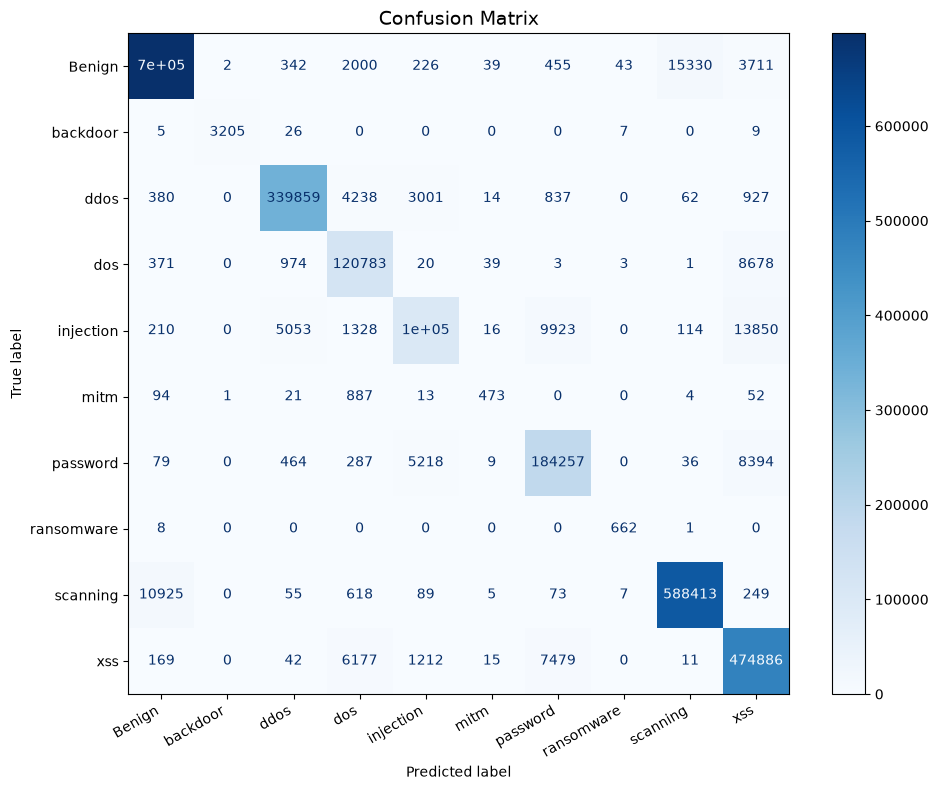

In [ ]:
def run_eval(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    AMP_ENABLED = DEVICE.type == "cuda"
    
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            # Sử dụng AMP để test nhanh và nhẹ VRAM hơn
            with torch.autocast(device_type="cuda" if AMP_ENABLED else "cpu", enabled=AMP_ENABLED, dtype=torch.float16):
                logits = model(xb)
                
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
            
    return {'pred': np.array(all_preds), 'true': np.array(all_labels)}

# --- Code cũ của bạn giữ nguyên ---
m = run_eval(model, test_loader)
res = metrics_from_confusion(m['true'], m['pred'], N_APT_PHASES)

print('\n===== TEST METRICS (TP/TN/FP/FN) =====')

def metrics_from_confusion(y_true, y_pred, n_classes):
    """Tính Accuracy/Precision/Recall/F1 từ TP, TN, FP, FN (one-vs-rest cho từng lớp):
       Accuracy  = (TP+TN)/(TP+TN+FP+FN)
       Precision = TP/(TP+FP)
       Recall    = TP/(TP+FN)
       F1        = 2*Precision*Recall/(Precision+Recall)"""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    total = cm.sum()
    TP = np.diag(cm).astype(np.float64)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = total - TP - FP - FN
    support = cm.sum(axis=1)

    def safe_div(a, b):
        return np.divide(a, b, out=np.zeros_like(a, dtype=np.float64), where=b > 0)

    acc_c  = safe_div(TP + TN, TP + TN + FP + FN)
    prec_c = safe_div(TP, TP + FP)
    rec_c  = safe_div(TP, TP + FN)
    f1_c   = safe_div(2 * prec_c * rec_c, prec_c + rec_c)

    w = support / support.sum()
    return {
        'cm': cm, 'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN, 'support': support,
        'per_class': pd.DataFrame({
            'TP': TP.astype(int), 'TN': TN.astype(int), 'FP': FP.astype(int), 'FN': FN.astype(int),
            'Accuracy': acc_c, 'Precision': prec_c, 'Recall': rec_c, 'F1': f1_c,
            'Support': support}, index=CLASS_NAMES),
        # Overall accuracy = tổng TP / tổng mẫu
        'acc': TP.sum() / total,
        # Precision/Recall tổng (weighted); F1 tổng chỉ dùng 1 công thức duy nhất
        'prec': (w * prec_c).sum(),
        'rec':  (w * rec_c).sum(),
    }

m = run_eval(model, test_loader)
res = metrics_from_confusion(m['true'], m['pred'], N_APT_PHASES)

print('\n===== TEST METRICS (TP/TN/FP/FN) =====')
print(f'Accuracy  : {res["acc"]:.4f}')
P, R = res['prec'], res['rec']
F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0.0   # F1 = 2*Precision*Recall/(Precision+Recall)
print(f'Precision : {P:.4f}')
print(f'Recall    : {R:.4f}')
print(f'F1-score  : {F1:.4f}')
print()
pd.set_option('display.width', 200)
print(res['per_class'].round(4).to_string())
print()
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=CLASS_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

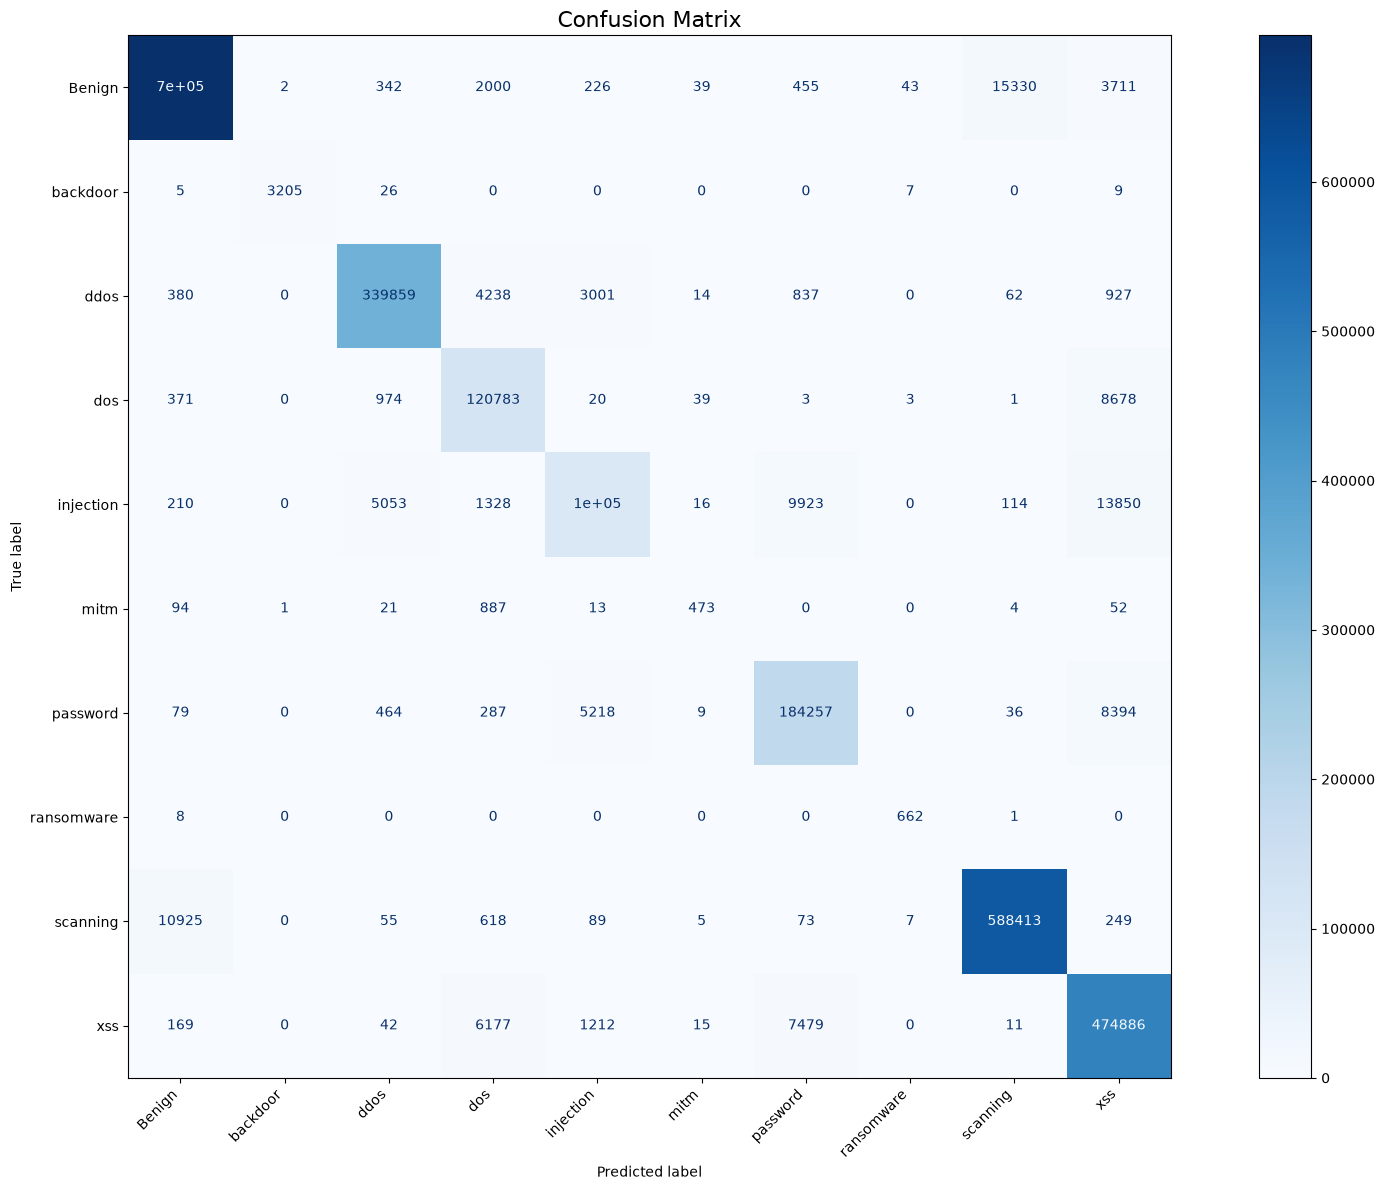

In [ ]:
# Tăng kích thước khung hình (chiều rộng x chiều cao) lên 18x12 (hoặc to hơn tùy ý)
fig, ax = plt.subplots(figsize=(18, 12)) 

ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=CLASS_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation='vertical') # Thêm xticks_rotation để xoay dọc nhãn nếu text quá dài

ax.set_title('Confusion Matrix', fontsize=16)

# Có thể giữ plt.xticks với góc 45 độ nếu xoay dọc (vertical) khó đọc
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()
